In [1]:
import pandas as pd
from sklearn.linear_model import LinearRegression
import numpy as np

In [2]:
df_meta = pd.read_excel("Data/top30k.xlsx")
print(f"meta columns: {df_meta.columns.tolist()}, dimention: {df_meta.shape}")

meta columns: ['main_category', 'title', 'average_rating', 'rating_number', 'features', 'description', 'price', 'images', 'videos', 'store', 'categories', 'details', 'parent_asin', 'bought_together', 'purchase_score', 'data', 'subtitle', 'author', 'image_path', 'caption'], dimention: (29999, 20)


In [6]:
np.log1p(df_meta['rating_number']).values.reshape(-1,1)

array([[1.94591015],
       [3.33220451],
       [0.69314718],
       ...,
       [1.09861229],
       [1.09861229],
       [0.69314718]])

In [8]:
# Log-transform to deal with skew
X = np.log1p(df_meta['rating_number']).values.reshape(-1,1)
y = df_meta['average_rating'].values

# fit regression model
reg = LinearRegression()
reg.fit(X, y)

# predict
df_meta['predicted_rating'] = reg.predict(X)

In [12]:
print(df_meta['predicted_rating'].values[:10])
print(df_meta['average_rating'].values[:10])

[4.05167383 4.23537801 3.88566451 4.2149508  3.93939454 4.05167383
 4.08497665 3.88566451 4.28591476 3.88566451]
[4.3 4.5 1.  4.5 5.  3.9 3.6 2.  4.6 5. ]


In [13]:
df_meta['adjust_rating'] = 0.7*df_meta['average_rating'] + 0.3 *df_meta['predicted_rating']

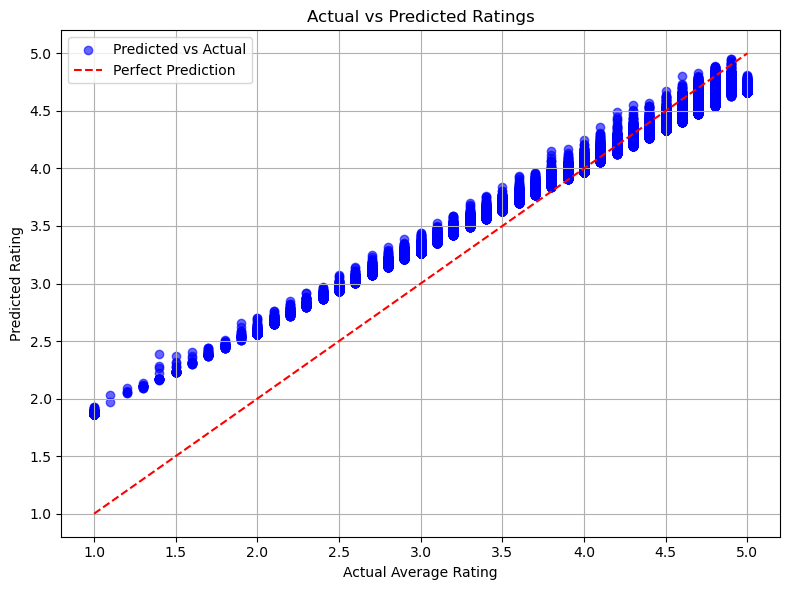

In [14]:
import matplotlib.pyplot as plt

# Plot actual vs predicted ratings
plt.figure(figsize=(8, 6))
plt.scatter(df_meta['average_rating'], df_meta['adjust_rating'], alpha=0.6, color='blue', label='Predicted vs Actual')

# Plot a 45-degree line for reference
plt.plot([df_meta['average_rating'].min(), df_meta['average_rating'].max()],
         [df_meta['average_rating'].min(), df_meta['average_rating'].max()],
         color='red', linestyle='--', label='Perfect Prediction')

plt.xlabel('Actual Average Rating')
plt.ylabel('Predicted Rating')
plt.title('Actual vs Predicted Ratings')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [1]:
import pickle
with open("Data/user_features.pkl", "rb") as f:
    user_features = pickle.load(f)
with open("Data/product_features.pkl", 'rb') as f:
    product_features = pickle.load(f)

In [1]:
import pandas as pd 
user_emb_path="Data/user_embeddings.csv"
product_emb_path = "Data/product_embeddings.csv"
user_df = pd.read_csv(user_emb_path, index_col=0)
product_df = pd.read_csv(product_emb_path, index_col=0)

In [2]:
user_df

,0,1,2,3,4,5,6,7,8,9,...,118,119,120,121,122,123,124,125,126,127
AE222FP7YRNFCEQ2W3ZDIGMSYTLQ,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,-0.024316,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
AE223N4K4ROAGJPN55UM3IYGGCOQ,-0.002614,-0.075165,0.047873,-0.058270,0.028321,0.075691,0.018950,0.234011,-0.059246,0.044884,...,-0.050144,0.068293,0.045675,-0.086957,-0.020765,-0.117614,0.038933,0.072390,0.073911,-0.309598
AE225KTEK4YRJE2TBGPJZEAXAA4Q,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,-0.024316,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
AE225NQR6TN6SUNMTF6O4T37TXPQ,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,-0.024316,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
AE225T2ZALMW2LGAWZGONMYD2VJA,-0.011199,-0.064673,0.033208,-0.031332,0.020692,0.073850,-0.003049,0.250044,-0.043496,0.021031,...,-0.033677,0.059353,0.024668,-0.062254,-0.008719,-0.078117,0.030568,0.065703,0.053348,-0.318912
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
AHZZKY3S6YCCJV2VH4HVJ3Y5IEDA,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,-0.024316,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
AHZZLN7P67CN7L4RODX665VBYQXQ,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,-0.024316,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
AHZZLTXCRUYXU6D7L7RJBWIQWQPA,-0.006300,0.036001,-0.059657,0.040621,-0.010503,-0.036212,-0.036586,0.182388,0.036632,-0.024316,...,0.029869,-0.034700,-0.039269,0.037986,0.032711,0.067358,-0.024675,-0.024117,-0.026575,-0.290325
AHZZMDXZ6ZC26RPBK5WQ77YP7XDQ,-0.095701,0.187757,-0.027924,0.095125,-0.006242,-0.051503,-0.212703,0.483810,0.088574,-0.074004,...,0.005440,-0.112895,-0.079850,0.060450,0.041163,0.072299,-0.142358,-0.062642,-0.116905,-0.140588


In [7]:
product_df.values

array([[ 0.01422878, -0.0971868 , -0.00157021, ...,  0.04905022,
         0.04006395, -0.06086544],
       [ 0.00282638, -0.07809745, -0.00894935, ...,  0.03180099,
         0.02594226, -0.09731391],
       [-0.00391052, -0.06681886, -0.01330918, ...,  0.02160959,
         0.0175987 , -0.11884883],
       ...,
       [-0.00702532, -0.06160421, -0.01532495, ...,  0.0168976 ,
         0.01374107, -0.12880549],
       [-0.01614413, -0.04633794, -0.02122625, ...,  0.00310292,
         0.00244756, -0.15795434],
       [ 0.00618341, -0.08371763, -0.00677683, ...,  0.03687941,
         0.03009988, -0.08658297]])

In [3]:
from sklearn.metrics.pairwise import cosine_similarity
user_emb = user_df.loc['AHZZLN7P67CN7L4RODX665VBYQXQ'].values.reshape(1, -1)

sim_scores = cosine_similarity(user_emb, product_df.values)[0]
sim_scores

array([-0.17489173,  0.24817215,  0.47052868, ...,  0.55310093,
        0.72229968,  0.12203715])

In [15]:
import numpy as np 
k = 5
top_k_idx = np.argsort(sim_scores)[::-1][:k]
top_k_products = product_df.index[top_k_idx]
top_k_scores = sim_scores[top_k_idx]

In [18]:
top_k_idx
top_k_products
top_k_scores

array([0.90820881, 0.90665976, 0.90441007, 0.90363789, 0.90084966])

In [5]:
df_product = pd.read_excel("Data/top30k.xlsx")


In [6]:
df_sub = df_product[df_product['parent_asin'].isin(['B0BKT4YYQQ', 'B01B8KIDZE', 'B07GC95M83', 
                                                           'B07RCJS5FK', 'B0B1GHFCS1', 'B09S13F9VD'])]

df_sub.to_excel("Top5SimilarProductsV2_detail.xlsx", index=False)
df_sub

,main_category,title,average_rating,rating_number,features,description,price,images,videos,store,categories,details,parent_asin,bought_together,purchase_score,data,subtitle,author,image_path,caption
13594,Tools & Home Improvement,"LG 4681ED1004E, Silver",4.2,19,"['This Is An O. E. M. Authorized Part', 'Count...",['This is a Genuine replacement LG part. Pleas...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'Supplying Demand 4681ED1004B Produ...,LG,"['Appliances', 'Parts & Accessories']","{'Manufacturer': 'LG', 'Part Number': '1026285...",B07GC95M83,NaN,1.0,2023-02-25 15:18:14.871,NaN,NaN,Data/images\B07GC95M83.jpg,a motor for a washing machine on a white backg...
14482,Tools & Home Improvement,UPGRADED WPW10710203 Refrigerator Door Bin She...,4.7,32,['【NOTICE -PLEASE READ】This WPW10710203/ W1071...,[],32.99,[{'thumb': 'https://m.media-amazon.com/images/...,[{'title': 'UPGRADED WPW10710203/W10710203 Ref...,ALVAR,"['Appliances', 'Parts & Accessories', 'Refrige...","{'Manufacturer': 'ALVAR', 'Part Number': 'WPW1...",B0BKT4YYQQ,NaN,1.0,2023-02-04 03:09:53.780,NaN,NaN,Data/images\B0BKT4YYQQ.jpg,a clear plastic shelf with four cans and two b...
17648,Tools & Home Improvement,"Edgewater Parts WB21K38, AP2023294, PS235455 B...",3.2,9,"['Edgewater Parts WB21K38, AP2023294, PS235455...","['Fits Models: JGBS22BEA2WH,RGB524PEA6WH,JGBP2...",34.55,[{'thumb': 'https://m.media-amazon.com/images/...,[],Edgewater Parts,"['Appliances', 'Parts & Accessories']","{'Manufacturer': 'Edgewater Parts', 'Part Numb...",B01B8KIDZE,NaN,1.0,2022-11-17 00:08:12.144,NaN,NaN,Data/images\B01B8KIDZE.jpg,a small metal switch with a metal housing\n
18201,Tools & Home Improvement,UPGRADED Lifetime Appliance WH13X10029 Inlet O...,3.9,12,"['✅ Part Numbers: WH13X10029, AP4303282, 14757...","['SPECIFICATIONS', ""Compatible with GE WasherR...",20.00,[{'thumb': 'https://m.media-amazon.com/images/...,"[{'title': 'Lifetime Appliance Parts Intro', '...",Lifetime Appliance Parts,"['Appliances', 'Parts & Accessories', 'Dryer P...","{'Manufacturer': 'Lifetime Appliance Parts', '...",B0B1GHFCS1,NaN,1.0,2022-11-01 20:49:57.926,NaN,NaN,Data/images\B0B1GHFCS1.jpg,two white plastic valves on a white background\n
18971,Tools & Home Improvement,WB24T10025 for GE Electric Range Burner Unit I...,5.0,1,['WB24T10025 for GE Electric Range Burner Unit...,['NEW LARGE BURNER SWITCH BY ROBERTSHAW FOR WB...,45.98,[{'thumb': 'https://m.media-amazon.com/images/...,[],Greatshow,"['Appliances', 'Parts & Accessories', 'Range P...","{'Manufacturer': 'Greatshow', 'Part Number': '...",B07RCJS5FK,NaN,1.0,2022-10-11 18:33:03.360,NaN,NaN,Data/images\B07RCJS5FK.jpg,two white and gray electronic switches on a wh...
19306,Tools & Home Improvement,Replacement for 154388801 Dispenser Cap Compat...,5.0,1,['Replace part numbers:154388801 (AP2109579) r...,['Replacement for 154388801 Dispenser Cap Comp...,NaN,[{'thumb': 'https://m.media-amazon.com/images/...,[],cbrsit,"['Appliances', 'Parts & Accessories', 'Dishwas...","{'Manufacturer': 'cbrsit', 'Part Number': 'CB2...",B09S13F9VD,NaN,1.0,2022-10-02 22:44:40.629,NaN,NaN,Data/images\B09S13F9VD.jpg,a white plastic lid with a gray handle\n


In [4]:
aa = {'a':1, 'b':2}
list(aa.keys())

['a', 'b']